 # Exploratory Data Analysis (EDA)

## Objectives

- Understand customer behavior.
- Discover patterns associated with churn.
- Identify important predictive features.
- Detect outliers.
- Generate business insights for model building.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/raw/Churn_Modelling.csv")#

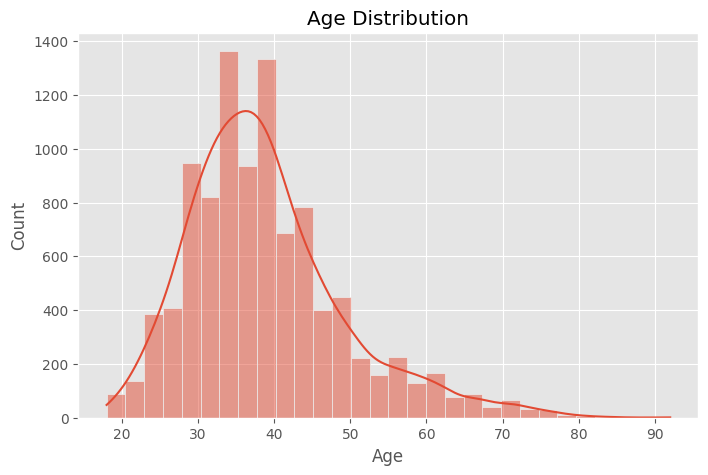

In [3]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

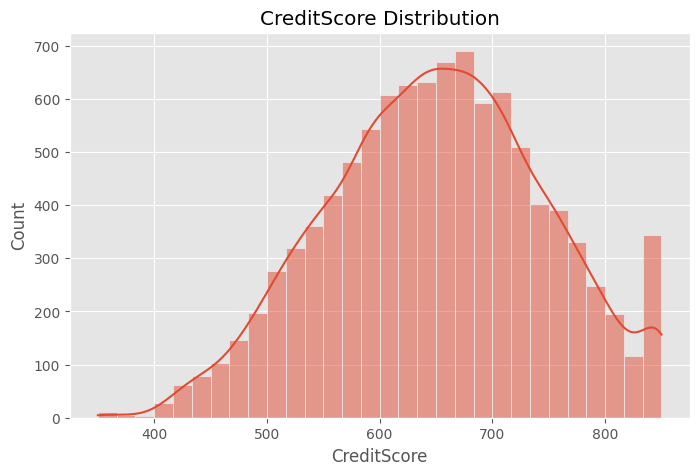

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df["CreditScore"], bins=30, kde=True)
plt.title("CreditScore Distribution")
plt.show()

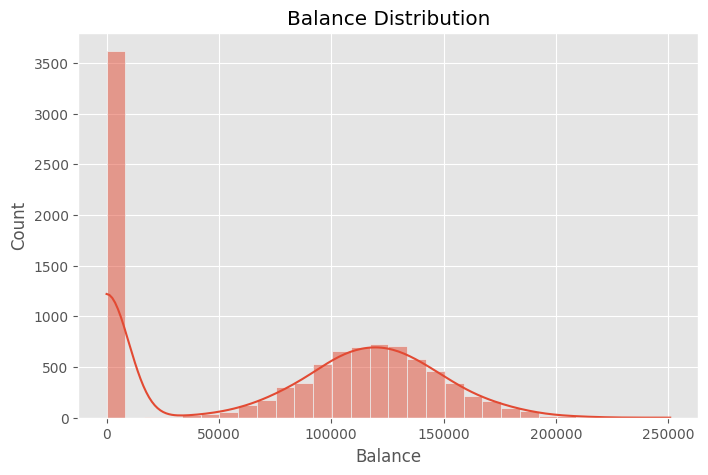

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df[ "Balance"], bins=30, kde=True)
plt.title("Balance Distribution")
plt.show()

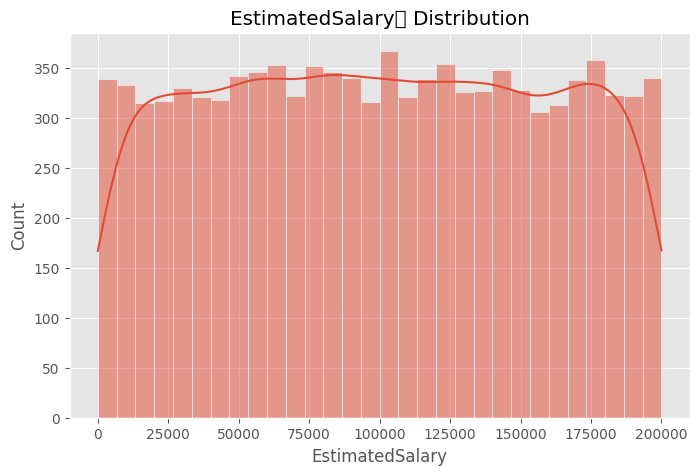

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df["EstimatedSalary"], bins=30, kde=True)
plt.title("EstimatedSalary	 Distribution")
plt.show()

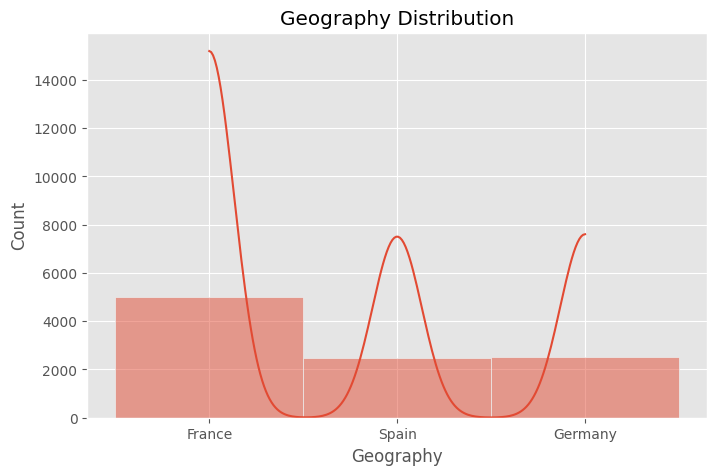

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["Geography"], bins=30, kde=True)
plt.title("Geography Distribution")
plt.show()

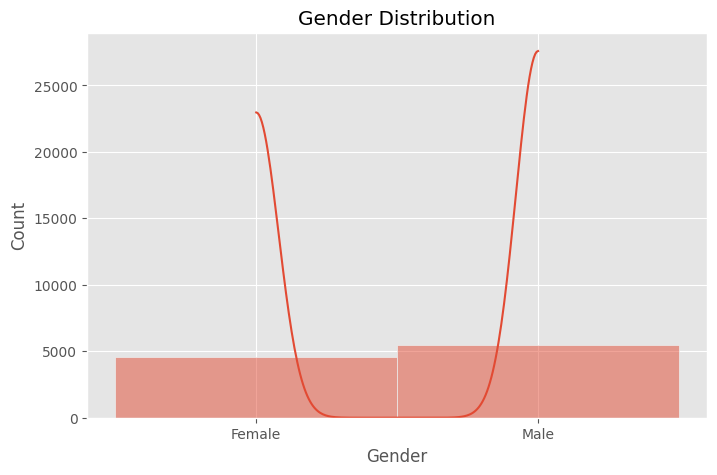

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["Gender"], bins=30, kde=True)
plt.title("Gender Distribution")
plt.show()

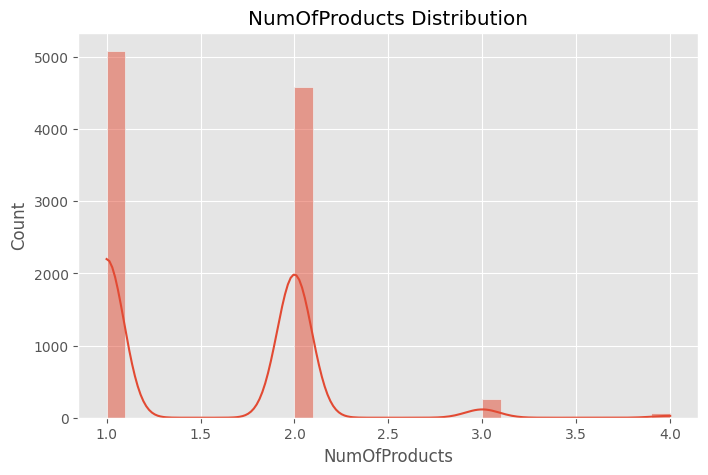

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["NumOfProducts"], bins=30, kde=True)
plt.title("NumOfProducts Distribution")
plt.show()

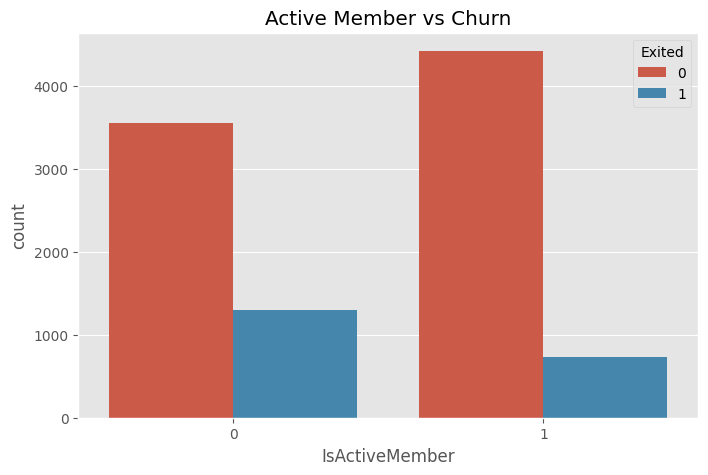

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df["IsActiveMember"], bins=30, kde=True)
plt.title("IsActiveMember Distribution")
plt.show()

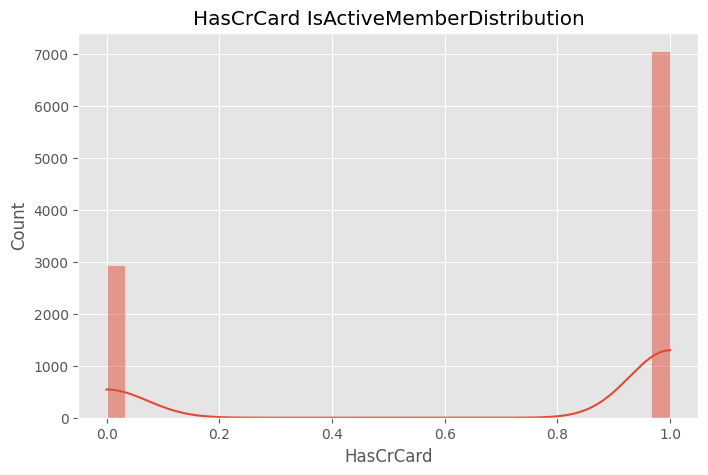

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df["HasCrCard"], bins=30, kde=True)
plt.title("HasCrCard IsActiveMemberDistribution")
plt.show()

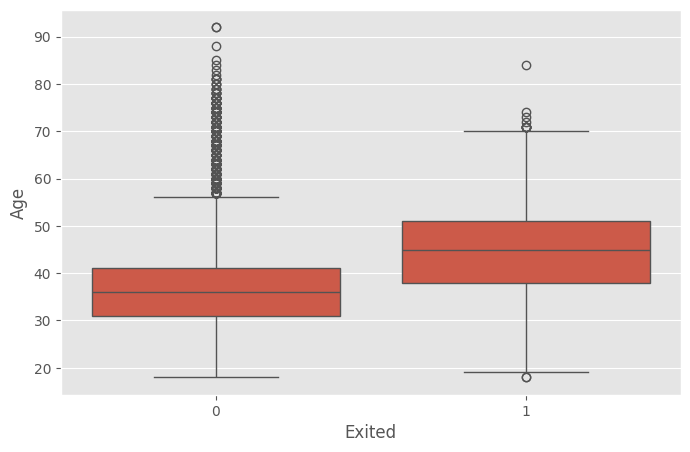

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df,x="Exited",y="Age")
plt.show()

<Axes: xlabel='Geography', ylabel='count'>

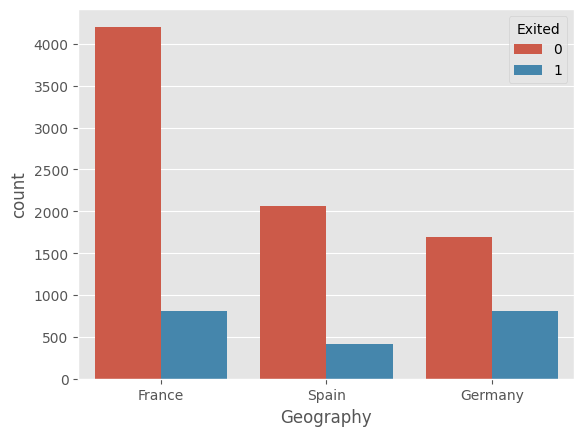

In [16]:
sns.countplot(
    data=df,
    x="Geography",
    hue="Exited"
)

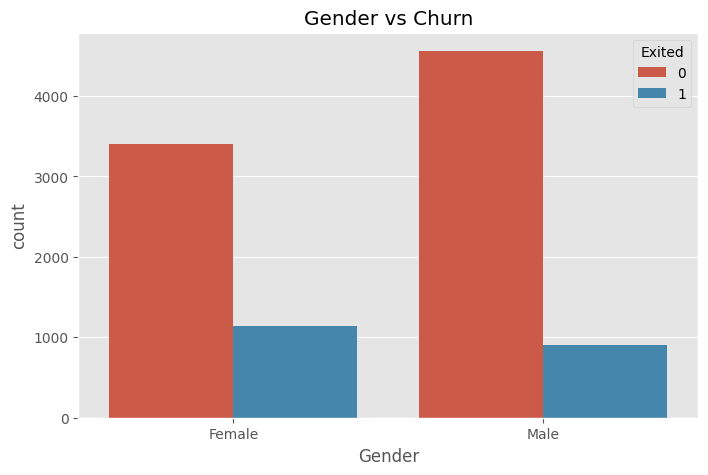

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Gender", hue="Exited")
plt.title("Gender vs Churn")
plt.show()

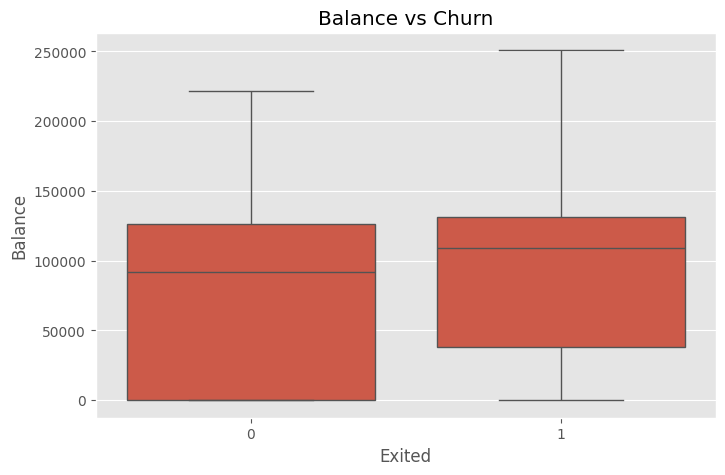

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Exited", y="Balance")
plt.title("Balance vs Churn")
plt.show()

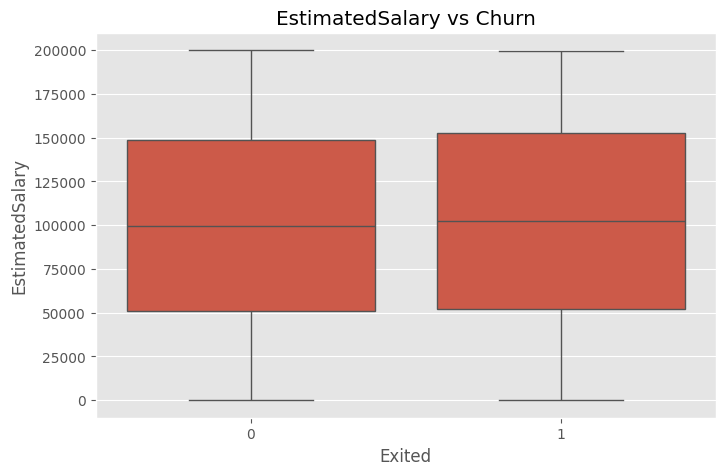

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Exited", y="EstimatedSalary")
plt.title("EstimatedSalary vs Churn")
plt.show()

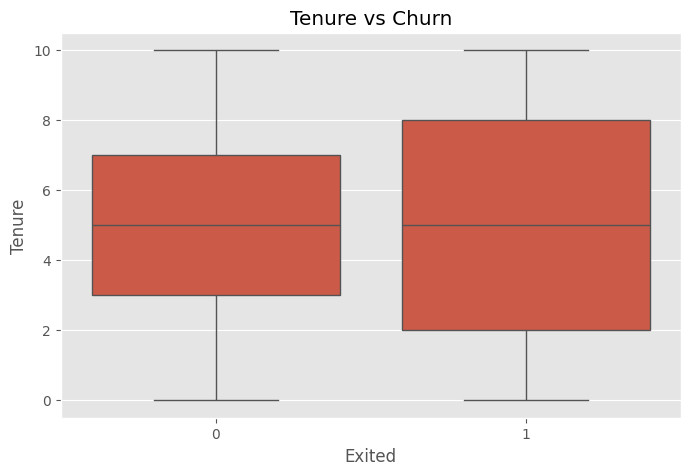

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Exited", y="Tenure")
plt.title("Tenure vs Churn")
plt.show()

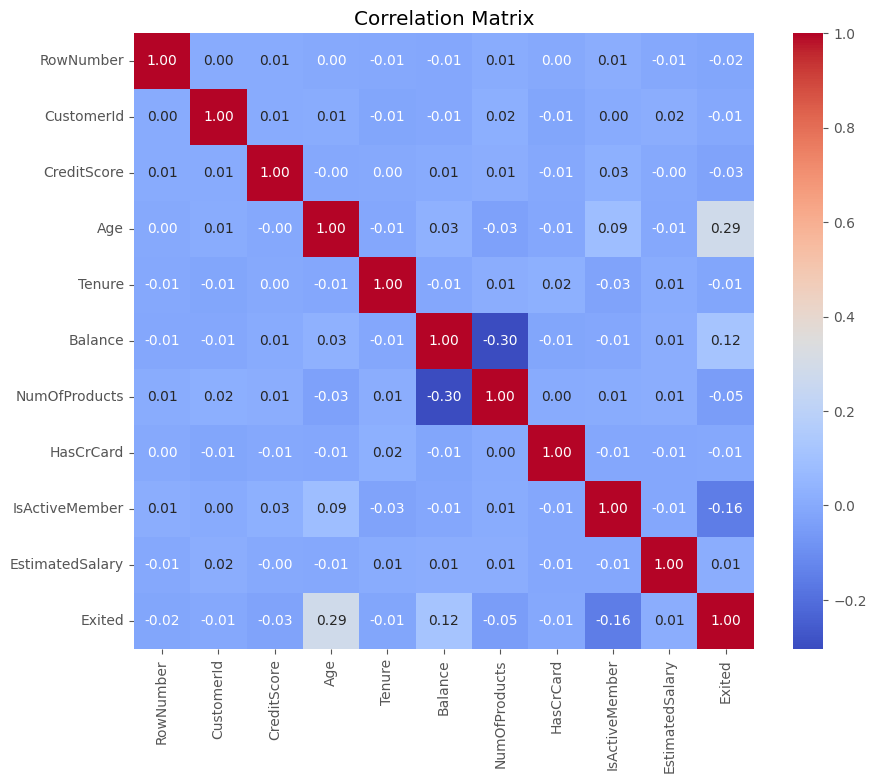

In [21]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [24]:
churn_by_geography = df.groupby('Geography')['Exited'].mean().reset_index()
churn_by_geography['Exited'] = churn_by_geography['Exited'] * 100 # Convert to percentage
churn_by_geography = churn_by_geography.rename(columns={'Exited': 'ChurnRate_Percentage'})
display(churn_by_geography.sort_values(by='ChurnRate_Percentage', ascending=False))

,Geography,ChurnRate_Percentage
1,Germany,32.443204
2,Spain,16.673395
0,France,16.154767


In [25]:
numerical = [
    "CreditScore",
    "Age",
    "Balance",
    "EstimatedSalary"
]

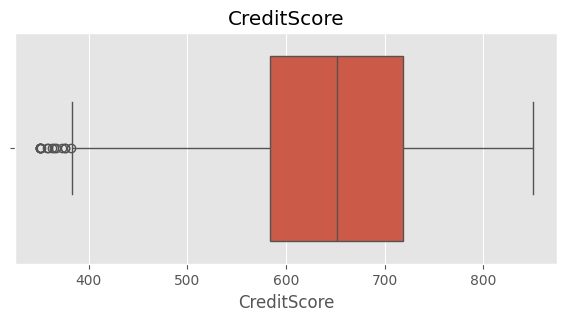

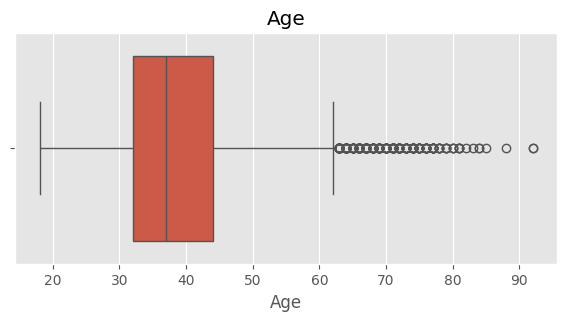

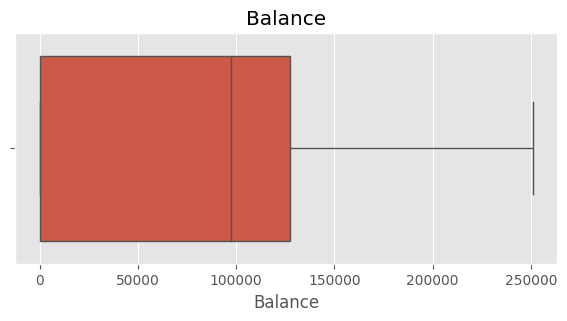

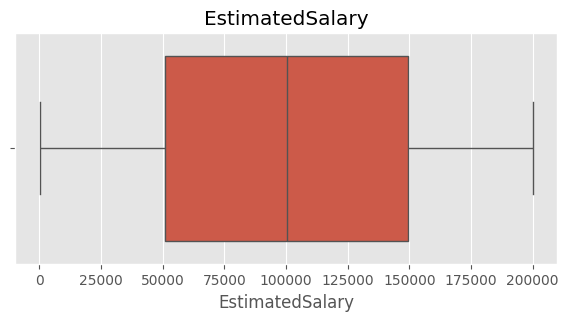

In [26]:
for col in numerical:

    plt.figure(figsize=(7,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

## Key Insights

- The dataset is moderately imbalanced (79.63% retained vs 20.37% churned).
- Age shows a noticeable relationship with customer churn.
- Inactive customers exhibit a substantially higher churn rate.
- Germany records the highest churn percentage among all geographical regions.
- Estimated Salary has little visible influence on churn.
- Several numerical features contain outliers that will be assessed during preprocessing.
- CustomerId, RowNumber, and Surname are unlikely to provide predictive value and will be evaluated for removal.